# 📓 `11_drl_ppo_agent.ipynb`

---

# 📓 Week 11 — PPO-Based DRL Self-Healing Agent

## Project Context
**Part 1 (Weeks 1–10):** SecurityBERT detects IoT attacks → outputs 15-class
probability vector from network traffic.

**Part 2 (Weeks 11–14, this notebook onward):** DRL Self-Healing Agent
receives SecurityBERT's output and decides what *action* to take to
mitigate the detected threat automatically.

---

## 🎯 Week 11 Objective
Build the **PPO agent skeleton**:
- Define state space (what the agent sees)
- Define action space (what the agent can do)
- Define reward function (what "good" means)
- Implement PPO Actor-Critic network
- Implement full PPO training loop
- Save trained agent → `checkpoints/ppo_agent.pt`

---

## 🏗️ System Design

```
SecurityBERT Output (from Part 1)
    attack_probs: [0.02, 0.0, 0.0, 0.94, ...]   ← 15-class softmax
         ↓
┌────────────────────────────────────────────┐
│          DRL Self-Healing Agent             │
│                                            │
│  State  (30-dim):
│    [attack_probs(15)
│     + network_stats(10)
│     + action_history(5)]
│
│  Actor  → π(a|s) → action
│  Critic → V(s)   → value estimate
│
│  PPO Update:
│    L = min(r·A, clip(r,1-ε,1+ε)·A)
└────────────────────────────────────────────┘
         ↓
   Action chosen: BLOCK_IP
         ↓
   Week 14: SelfHealingManager executes action

```

---

## 📋 Notebook Roadmap

| Step | Task |
|------|------|
| 1 | Imports & Constants |
| 2 | Domain definitions (actions, rewards, classes) |
| 3 | NetworkSecurityEnv — simulation environment |
| 4 | PPO Actor-Critic network |
| 5 | Rollout buffer |
| 6 | PPO Agent (GAE + clipped update) |
| 7 | Training loop (2,000 episodes) |
| 8 | Training curves |
| 9 | Evaluation |
| 10 | Save checkpoint |

---

## 🧱 Step 1 — Imports & Constants

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import json
import time
import math
import random
from pathlib     import Path
from typing      import List, Tuple, Dict, Optional
from collections import deque, defaultdict

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn            as nn
import torch.nn.functional as F
from torch.optim           import Adam
from torch.distributions   import Categorical

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#16162a',
    'axes.edgecolor' : '#444477', 'axes.labelcolor': '#ccccff',
    'xtick.color'    : '#aaaacc', 'ytick.color'    : '#aaaacc',
    'text.color'     : '#e0e0ff', 'grid.color'     : '#2a2a4a',
    'grid.linestyle' : '--',      'grid.alpha'     : 0.4,
    'font.family'    : 'DejaVu Sans',
    'legend.facecolor': '#1a1a2e','legend.edgecolor': '#444477',
})
ACCENT = '#7c6cfa'; GREEN = '#4ecca3'; RED = '#fc5c65'
YELLOW = '#f7b731'; BLUE  = '#45aaf2'; ORANGE = '#fd9644'
PALETTE = ['#7c6cfa','#4ecca3','#f7b731','#fc5c65','#45aaf2',
           '#fd9644','#26de81','#a55eea','#2bcbba','#eb3b5a',
           '#20bf6b','#0fb9b1','#8854d0','#4b6584','#778ca3']

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path('..')
CKPT_DIR   = BASE_DIR / 'checkpoints'
OUT_DIR    = BASE_DIR / 'outputs' / 'figures' / 'N11'
REP_DIR    = BASE_DIR / 'outputs' / 'reports'

# NB11 saves these:
BEST_CKPT  = CKPT_DIR / 'ppo_agent.pt'       # best by rolling reward
LAST_CKPT  = CKPT_DIR / 'ppo_agent_last.pt'  # last episode

for d in [CKPT_DIR, OUT_DIR, REP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ─────────────────────────────────────────────────────────────────────────────
# DOMAIN CONSTANTS
# These are shared between NB11 and NB12 — do NOT change them.
# CLASS_NAMES order matches label_map from NB04/NB05 (alphabetical).
# ─────────────────────────────────────────────────────────────────────────────

# 15 attack classes — alphabetical order from Edge-IIoTset label_map
CLASS_NAMES = [
    'Backdoor',            # 0
    'DDoS_HTTP',           # 1
    'DDoS_ICMP',           # 2
    'DDoS_TCP',            # 3
    'DDoS_UDP',            # 4
    'Fingerprinting',      # 5
    'MITM',                # 6
    'Normal',              # 7
    'Password',            # 8
    'Port_Scanning',       # 9
    'Ransomware',          # 10
    'SQL_injection',       # 11
    'Uploading',           # 12
    'Vulnerability_scanner',# 13
    'XSS',                 # 14
]

# 5 healing actions
ACTION_NAMES = [
    'BLOCK_IP',            # 0 — iptables DROP source IP
    'RESET_CONNECTION',    # 1 — TCP RST / session teardown
    'RESTART_SERVICE',     # 2 — restart compromised service
    'ISOLATE_DEVICE',      # 3 — block ALL traffic from device
    'LOG_AND_ALERT',       # 4 — log + SMTP email, no disruption
]

N_CLASSES   = len(CLASS_NAMES)   # 15
N_ACTIONS   = len(ACTION_NAMES)  # 5
N_NET_STATS = 10                 # network state features
N_HISTORY   = 5                  # recent action history window
STATE_DIM   = N_CLASSES + N_NET_STATS + N_HISTORY  # 30

# Class index lookup
CLS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}

# ── Correct healing action per attack class ───────────────────────────────────
OPTIMAL_ACTION: Dict[str, int] = {
    'Normal'                : 4,   # LOG_AND_ALERT  — no threat
    'Fingerprinting'        : 4,   # LOG_AND_ALERT  — low severity
    'Port_Scanning'         : 0,   # BLOCK_IP
    'DDoS_TCP'              : 0,   # BLOCK_IP
    'DDoS_UDP'              : 0,   # BLOCK_IP
    'DDoS_ICMP'             : 0,   # BLOCK_IP
    'DDoS_HTTP'             : 0,   # BLOCK_IP
    'SQL_injection'         : 1,   # RESET_CONNECTION
    'XSS'                   : 1,   # RESET_CONNECTION
    'MITM'                  : 1,   # RESET_CONNECTION
    'Uploading'             : 2,   # RESTART_SERVICE
    'Backdoor'              : 2,   # RESTART_SERVICE
    'Password'              : 2,   # RESTART_SERVICE
    'Vulnerability_scanner' : 2,   # RESTART_SERVICE
    'Ransomware'            : 3,   # ISOLATE_DEVICE — most severe
}

# Severity score (0=benign → 10=critical)
CLASS_SEVERITY: Dict[str, int] = {
    'Normal': 0, 'Fingerprinting': 1, 'Port_Scanning': 2,
    'Vulnerability_scanner': 3, 'DDoS_ICMP': 4, 'DDoS_HTTP': 4,
    'DDoS_UDP': 4, 'DDoS_TCP': 5, 'XSS': 5, 'SQL_injection': 6,
    'MITM': 7, 'Password': 7, 'Uploading': 7,
    'Backdoor': 8, 'Ransomware': 10,
}

# Network disruption cost of each action
ACTION_COST: Dict[int, float] = {
    0: 0.30,   # BLOCK_IP
    1: 0.20,   # RESET_CONNECTION
    2: 0.40,   # RESTART_SERVICE
    3: 0.80,   # ISOLATE_DEVICE
    4: 0.05,   # LOG_AND_ALERT
}

# Rare classes — get extra attention in Week 12 curriculum
RARE_CLASSES = {'MITM', 'Fingerprinting', 'Ransomware'}

# ── PPO Hyperparameters ───────────────────────────────────────────────────────
PPO_LR           = 3e-4
PPO_GAMMA        = 0.99
PPO_GAE_LAMBDA   = 0.95
PPO_CLIP_EPS     = 0.20
PPO_EPOCHS       = 10
PPO_BATCH_SIZE   = 64
PPO_VALUE_COEF   = 0.50
PPO_ENTROPY_COEF = 0.01
PPO_MAX_GRAD     = 0.50
HIDDEN_DIM       = 128

# Training config
N_EPISODES    = 2_000
MAX_STEPS     = 200
UPDATE_EVERY  = 20     # collect 20 episodes then do PPO update
TARGET_REWARD = 0.70   # Week 12 milestone

print('✅ Setup complete.')
print(f'   Device     : {DEVICE}')
print(f'   State dim  : {STATE_DIM}  '
      f'({N_CLASSES} classes + {N_NET_STATS} net_stats + {N_HISTORY} history)')
print(f'   Actions    : {N_ACTIONS}  → {ACTION_NAMES}')
print(f'   Classes    : {N_CLASSES}')
print(f'   Target     : reward ≥ {TARGET_REWARD}  (Week 12 milestone)')

✅ Setup complete.
   Device     : cuda
   State dim  : 30  (15 classes + 10 net_stats + 5 history)
   Actions    : 5  → ['BLOCK_IP', 'RESET_CONNECTION', 'RESTART_SERVICE', 'ISOLATE_DEVICE', 'LOG_AND_ALERT']
   Classes    : 15
   Target     : reward ≥ 0.7  (Week 12 milestone)


## 🌐 Step 3 — Network Security Environment

Simulates an IoT network under attack. The environment:
1. Samples a random attack class (weighted by realism)
2. Simulates SecurityBERT's probability output for that attack
3. Generates network statistics matching that attack's signature
4. Receives the agent's healing action
5. Returns a reward based on correctness

### State Vector (dim=30)
```
s = [
    attack_probs[0:15],   ← SecurityBERT softmax probabilities
    net_stats[15:25],     ← connection_rate, cpu, memory, etc.
    history[25:30],       ← last 5 actions taken (normalised)
]
```

### Reward (Week 11 — simple version)
```
Correct action for detected threat   → +1.0
Correct on Normal (LOG_AND_ALERT)    → +0.5
Wrong action on attack               → −0.5 × severity
False positive on Normal             → −0.3
Repeated wrong action                → −0.2 additional
```
*Week 12 will replace this with shaped rewards + curriculum.*

In [2]:
class NetworkSecurityEnv:
    """
    IoT Network Security Simulation Environment.

    Simulates the IoT network that SecurityBERT monitors.
    The DRL agent interacts with this environment during training.

    State (dim=30):
        [attack_probs(15) | net_stats(10) | action_history(5)]

    Action (discrete, 5):
        0: BLOCK_IP
        1: RESET_CONNECTION
        2: RESTART_SERVICE
        3: ISOLATE_DEVICE
        4: LOG_AND_ALERT

    NB12 extends this class — do NOT rename any attributes.
    """

    def __init__(
        self,
        active_classes : Optional[List[str]] = None,
        max_steps      : int   = MAX_STEPS,
        noise_level    : float = 0.05,
        rng_seed       : int   = SEED,
    ):
        """
        Parameters
        ----------
        active_classes : classes to sample from (None = all 15)
        max_steps      : episode length
        noise_level    : Gaussian noise on network stats
        rng_seed       : random seed for reproducibility
        """
        self.all_classes    = CLASS_NAMES
        self.active_classes = active_classes or CLASS_NAMES
        self.max_steps      = max_steps
        self.noise_level    = noise_level
        self.rng            = np.random.RandomState(rng_seed)

        # State variables — set by reset() and _sample_threat()
        self.true_class     : str         = ''
        self.true_class_idx : int         = 0
        self.attack_probs   : np.ndarray  = np.zeros(N_CLASSES, np.float32)
        self.confidence     : float       = 0.0
        self.network_stats  : np.ndarray  = np.zeros(N_NET_STATS, np.float32)
        self.action_history : deque       = deque([0]*N_HISTORY, maxlen=N_HISTORY)
        self.step_count     : int         = 0
        self.resolved_count : int         = 0
        self.consecutive_bad: int         = 0

    # ── Public API ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

    def reset(self) -> np.ndarray:
        """Reset episode. Returns initial state."""
        self.step_count      = 0
        self.resolved_count  = 0
        self.consecutive_bad = 0
        self.action_history  = deque([0] * N_HISTORY, maxlen=N_HISTORY)
        self._sample_threat()
        return self._build_state()

    def step(self, action: int) -> Tuple[np.ndarray, float, bool, Dict]:
        """
        Execute one healing action.

        Returns
        -------
        next_state : np.ndarray (30,)
        reward     : float
        done       : bool
        info       : dict
        """
        self.step_count += 1
        self.action_history.append(action)

        reward, info = self._compute_reward(action)

        # Update network after action
        if info['is_correct']:
            self.consecutive_bad  = 0
            self.resolved_count  += 1
            self.network_stats    = np.clip(
                self.network_stats * 0.6
                + self.rng.normal(0.3, 0.05, N_NET_STATS).astype(np.float32),
                0.0, 1.0
            )
        else:
            self.consecutive_bad += 1
            self.network_stats    = np.clip(
                self.network_stats * 1.05
                + self.rng.normal(0.0, 0.05, N_NET_STATS).astype(np.float32),
                0.0, 1.0
            )

        # Sample new threat after resolution or every 10 steps
        if info['is_correct'] or self.step_count % 10 == 0:
            self._sample_threat()

        done = (
            self.step_count      >= self.max_steps or
            self.consecutive_bad >= 10
        )

        info.update({
            'true_class'    : self.true_class,
            'action_name'   : ACTION_NAMES[action],
            'optimal_action': ACTION_NAMES[OPTIMAL_ACTION[self.true_class]],
            'step'          : self.step_count,
        })

        return self._build_state(), float(reward), done, info

    # ── Internal methods (NB12 overrides _sample_threat + _compute_reward) ────

    def _sample_threat(self) -> None:
        """
        Sample a new threat from active_classes.
        NB12 CurriculumSecurityEnv overrides this to use curriculum weights.
        """
        idx                  = self.rng.randint(0, len(self.active_classes))
        self.true_class      = self.active_classes[idx]
        self.true_class_idx  = CLS_TO_IDX[self.true_class]
        self.attack_probs    = self._simulate_probs()
        self.confidence      = float(self.attack_probs[self.true_class_idx])
        self.network_stats   = self._simulate_net_stats()

    def _simulate_probs(self) -> np.ndarray:
        """
        Simulate SecurityBERT's softmax output for current threat.
        85% chance: high-confidence correct detection (conf 0.70–0.95)
        15% chance: ambiguous / confused detection
        """
        probs = np.zeros(N_CLASSES, dtype=np.float32)

        if self.rng.random() < 0.85:
            conf = 0.70 + self.rng.random() * 0.25
            probs[self.true_class_idx] = conf
            # Distribute remaining probability
            other = [i for i in range(N_CLASSES) if i != self.true_class_idx]
            noise = self.rng.dirichlet(np.ones(len(other)) * 0.5)
            for i, oi in enumerate(other):
                probs[oi] = noise[i] * (1.0 - conf)
        else:
            # Low-confidence detection
            probs = self.rng.dirichlet(np.ones(N_CLASSES) * 0.3).astype(np.float32)

        return probs

    def _simulate_net_stats(self) -> np.ndarray:
        """
        Simulate 10 network statistics for current attack type.

        Features (normalised 0-1):
            [0] connection_rate  [1] packet_loss   [2] cpu_load
            [3] memory_usage     [4] active_conns  [5] error_rate
            [6] bandwidth_util   [7] latency_ms    [8] retry_count
            [9] alert_count
        """
        # Attack-specific network signatures
        SIGNATURES = {
            'DDoS_TCP'   : [0.9,0.6,0.9,0.7,0.9,0.7,0.9,0.8,0.8,0.8],
            'DDoS_UDP'   : [0.9,0.7,0.8,0.6,0.9,0.8,0.9,0.9,0.7,0.8],
            'DDoS_ICMP'  : [0.8,0.5,0.7,0.5,0.8,0.6,0.8,0.8,0.6,0.7],
            'DDoS_HTTP'  : [0.7,0.4,0.8,0.8,0.7,0.5,0.8,0.7,0.5,0.7],
            'Ransomware' : [0.3,0.2,0.9,0.9,0.3,0.4,0.6,0.3,0.4,0.9],
            'SQL_injection':[0.4,0.1,0.5,0.4,0.4,0.3,0.3,0.3,0.2,0.6],
            'MITM'       : [0.3,0.3,0.4,0.4,0.3,0.4,0.4,0.5,0.3,0.7],
            'Backdoor'   : [0.2,0.1,0.6,0.7,0.2,0.3,0.4,0.2,0.2,0.8],
            'Port_Scanning':[0.6,0.1,0.3,0.2,0.6,0.2,0.4,0.3,0.3,0.4],
            'XSS'        : [0.3,0.1,0.4,0.4,0.3,0.4,0.3,0.3,0.2,0.5],
            'Password'   : [0.2,0.1,0.4,0.3,0.2,0.2,0.2,0.2,0.5,0.6],
            'Normal'     : [0.3,0.1,0.4,0.5,0.3,0.1,0.4,0.2,0.1,0.1],
        }
        base = SIGNATURES.get(
            self.true_class,
            [0.3,0.1,0.4,0.5,0.3,0.1,0.4,0.2,0.1,0.1]
        )
        sig   = np.array(base, dtype=np.float32)
        noise = self.rng.normal(0.0, self.noise_level, N_NET_STATS).astype(np.float32)
        return np.clip(sig + noise, 0.0, 1.0)

    def _compute_reward(self, action: int) -> Tuple[float, Dict]:
        """
        Week 11 reward function — simple version.
        NB12 CurriculumSecurityEnv overrides this with shaped rewards.
        """
        optimal    = OPTIMAL_ACTION[self.true_class]
        is_correct = (action == optimal)
        is_normal  = (self.true_class == 'Normal')
        severity   = CLASS_SEVERITY[self.true_class]
        sev_norm   = severity / 10.0

        # Check for repeated wrong action
        hist = list(self.action_history)
        is_repeated = (
            len(hist) >= 2 and
            hist[-1] == action and
            hist[-2] == action and
            not is_correct
        )

        if is_normal and action == 4:
            reward = +0.50
        elif is_normal and action != 4:
            reward = -0.30 * ACTION_COST[action]
        elif is_correct:
            reward = +1.00 * max(self.confidence, 0.50)
        else:
            reward = -0.50 * (0.5 + sev_norm * 0.5)

        if is_repeated:
            reward -= 0.20

        return float(reward), {'is_correct': is_correct, 'reward': reward}

    def _build_state(self) -> np.ndarray:
        """Concatenate state vector. Shape: (STATE_DIM=30,)."""
        history_enc = (
            np.array(list(self.action_history), dtype=np.float32) / N_ACTIONS
        )
        return np.concatenate([
            self.attack_probs,    # (15,)
            self.network_stats,   # (10,)
            history_enc,          # (5,)
        ]).astype(np.float32)


# ── Smoke test ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
env   = NetworkSecurityEnv()
s0    = env.reset()
s1, r, done, info = env.step(0)

print('✅ NetworkSecurityEnv smoke test:')
print(f'   State dim       : {s0.shape}  ✅ expected (30,)')
print(f'   State range     : [{s0.min():.3f}, {s0.max():.3f}]')
print(f'   attack_probs sum: {s0[:N_CLASSES].sum():.4f}  ✅ expected ≈1.0')
print(f'   First threat    : {env.true_class}')
print(f'   Reward          : {r:.4f}')
print(f'   is_correct      : {info["is_correct"]}')
print(f'   Optimal action  : {info["optimal_action"]}')

✅ NetworkSecurityEnv smoke test:
   State dim       : (30,)  ✅ expected (30,)
   State range     : [0.000, 0.760]
   attack_probs sum: 1.0000  ✅ expected ≈1.0
   First threat    : MITM
   Reward          : -0.6250
   is_correct      : False
   Optimal action  : RESET_CONNECTION


## 🧠 Step 4 — PPO Actor-Critic Network

```
State (30-dim)
      ↓
Backbone: Linear(30→128) → LayerNorm → ReLU
          Linear(128→128) → LayerNorm → ReLU
      ↓               ↓
 actor_head        critic_head
 Linear(128→64)    Linear(128→64)
 ReLU               ReLU
 Linear(64→5)      Linear(64→1)
 → logits          → V(s)
```

**⚠️ Important:** `actor_head` and `critic_head` are the canonical
attribute names. NB12 reuses this EXACT class — attribute names must
never change or `load_state_dict` will fail.

In [3]:
class PPOActorCritic(nn.Module):
    """
    PPO Actor-Critic for IoT network self-healing.

    CANONICAL ATTRIBUTE NAMES (shared with NB12 — do not rename):
        self.backbone    → shared feature extractor
        self.actor_head  → policy π(a|s)
        self.critic_head → state value V(s)
    """

    def __init__(
        self,
        state_dim : int = STATE_DIM,
        action_dim: int = N_ACTIONS,
        hidden_dim: int = HIDDEN_DIM,
    ):
        super().__init__()

        # ── Shared backbone ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
        )

        # ── Actor head (policy) ━━━━━━━━━━━━━━━━━━
        # CANONICAL NAME: actor_head
        self.actor_head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )

        # ── Critic head (value) ━━━━━━━━━━━━━━━━━━
        # CANONICAL NAME: critic_head
        self.critic_head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

        self._init_weights()

    def _init_weights(self) -> None:
        """Orthogonal initialisation — standard PPO practice."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=math.sqrt(2))
                nn.init.constant_(m.bias, 0.0)
        # Smaller gain for output layers
        nn.init.orthogonal_(self.actor_head[-1].weight,  gain=0.01)
        nn.init.orthogonal_(self.critic_head[-1].weight, gain=1.00)

    def forward(
        self, state: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Returns (action_logits, state_value)."""
        features = self.backbone(state)
        return self.actor_head(features), self.critic_head(features)

    def get_action_and_value(
        self,
        state : torch.Tensor,
        action: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Sample or evaluate an action.

        Returns
        -------
        action   : (batch,)
        log_prob : (batch,)
        entropy  : (batch,)
        value    : (batch,)
        """
        logits, value = self.forward(state)
        dist          = Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        return (
            action,
            dist.log_prob(action),
            dist.entropy(),
            value.squeeze(-1),
        )

    def get_value(self, state: torch.Tensor) -> torch.Tensor:
        """Return value estimate only."""
        _, value = self.forward(state)
        return value.squeeze(-1)


# ── Verify architecture ━━━━━━━━━━━━━━━━━━━━━━━━
_net   = PPOActorCritic(STATE_DIM, N_ACTIONS, HIDDEN_DIM)
_dummy = torch.randn(4, STATE_DIM)
_a, _lp, _ent, _v = _net.get_action_and_value(_dummy)

total_params = sum(p.numel() for p in _net.parameters())
print('✅ PPOActorCritic defined.')
print(f'   Total parameters : {total_params:,}')
print(f'   State dim        : {STATE_DIM}')
print(f'   Action dim       : {N_ACTIONS}')
print()
print('📋 Canonical attribute names (NB12 must match):')
for name, _ in _net.named_modules():
    if name in ('backbone', 'actor_head', 'critic_head'):
        print(f'   ✅ self.{name}')
print()
print('📤 Output shapes:')
print(f'   action   : {tuple(_a.shape)}')
print(f'   log_prob : {tuple(_lp.shape)}')
print(f'   entropy  : {tuple(_ent.shape)}')
print(f'   value    : {tuple(_v.shape)}')
del _net, _dummy, _a, _lp, _ent, _v

✅ PPOActorCritic defined.
   Total parameters : 37,894
   State dim        : 30
   Action dim       : 5

📋 Canonical attribute names (NB12 must match):
   ✅ self.backbone
   ✅ self.actor_head
   ✅ self.critic_head

📤 Output shapes:
   action   : (4,)
   log_prob : (4,)
   entropy  : (4,)
   value    : (4,)


## 📦 Step 5 — Rollout Buffer

In [4]:
class RolloutBuffer:
    """
    Stores one rollout (multiple episodes) of transitions
    for the PPO batch update.

    Fields saved per step:
        state, action, log_prob, reward, value, done
    """

    __slots__ = ['states','actions','log_probs','rewards','values','dones']

    def __init__(self):
        self.states    : List[np.ndarray] = []
        self.actions   : List[int]        = []
        self.log_probs : List[float]      = []
        self.rewards   : List[float]      = []
        self.values    : List[float]      = []
        self.dones     : List[float]      = []

    def add(
        self,
        state   : np.ndarray,
        action  : int,
        log_prob: float,
        reward  : float,
        value   : float,
        done    : float,
    ) -> None:
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(done)

    def clear(self) -> None:
        for field in self.__slots__:
            getattr(self, field).clear()

    def __len__(self) -> int:
        return len(self.states)


print('✅ RolloutBuffer defined.')

✅ RolloutBuffer defined.


## 🤖 Step 6 — PPO Agent

Implements **Proximal Policy Optimization** (Schulman et al., 2017):

```
Collect rollout → Compute GAE advantages → PPO update

PPO loss:
  ratio    = π_θ(a|s) / π_θ_old(a|s)
  L_clip   = min(ratio·A, clip(ratio, 1-ε, 1+ε)·A)
  L_value  = MSE(V(s), returns)
  L_entropy= H[π]  (encourages exploration)
  L_total  = -L_clip + c1·L_value - c2·L_entropy
```

In [5]:
class PPOAgent:
    """
    PPO Agent for IoT network self-healing.

    NB12 loads this agent's checkpoint for warm-start training.
    The network architecture (PPOActorCritic) and checkpoint format
    must remain compatible between NB11 and NB12.
    """

    def __init__(
        self,
        state_dim    : int   = STATE_DIM,
        action_dim   : int   = N_ACTIONS,
        hidden_dim   : int   = HIDDEN_DIM,
        lr           : float = PPO_LR,
        gamma        : float = PPO_GAMMA,
        gae_lambda   : float = PPO_GAE_LAMBDA,
        clip_eps     : float = PPO_CLIP_EPS,
        ppo_epochs   : int   = PPO_EPOCHS,
        batch_size   : int   = PPO_BATCH_SIZE,
        value_coef   : float = PPO_VALUE_COEF,
        entropy_coef : float = PPO_ENTROPY_COEF,
        max_grad_norm: float = PPO_MAX_GRAD,
        device       : torch.device = DEVICE,
    ):
        self.gamma        = gamma
        self.gae_lambda   = gae_lambda
        self.clip_eps     = clip_eps
        self.ppo_epochs   = ppo_epochs
        self.batch_size   = batch_size
        self.value_coef   = value_coef
        self.entropy_coef = entropy_coef
        self.max_grad_norm= max_grad_norm
        self.device       = device

        self.network      = PPOActorCritic(
            state_dim, action_dim, hidden_dim
        ).to(device)
        self.optimizer    = Adam(
            self.network.parameters(), lr=lr, eps=1e-5
        )
        self.buffer       = RolloutBuffer()

        # Stats (persisted in checkpoint for NB12)
        self.total_steps  = 0
        self.update_count = 0
        self.best_reward  = -float('inf')

    @torch.no_grad()
    def select_action(
        self, state: np.ndarray
    ) -> Tuple[int, float, float]:
        """
        Select action from current policy.

        Returns
        -------
        action   : int
        log_prob : float
        value    : float
        """
        s         = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        a, lp, _, v = self.network.get_action_and_value(s)
        return a.item(), lp.item(), v.item()

    def compute_gae(
        self, last_value: float
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Generalised Advantage Estimation (GAE-λ).

        δt = rt + γ·V(st+1)·(1−done) − V(st)
        At = δt + γλ·(1−done)·At+1
        """
        N    = len(self.buffer)
        advs = np.zeros(N, dtype=np.float32)
        gae  = 0.0

        for t in reversed(range(N)):
            next_val  = last_value if t == N - 1 else self.buffer.values[t + 1]
            next_done = self.buffer.dones[t]
            delta     = (
                self.buffer.rewards[t]
                + self.gamma * next_val * (1.0 - next_done)
                - self.buffer.values[t]
            )
            gae       = (
                delta
                + self.gamma * self.gae_lambda * (1.0 - next_done) * gae
            )
            advs[t]   = gae

        returns = advs + np.array(self.buffer.values, dtype=np.float32)
        return torch.FloatTensor(advs), torch.FloatTensor(returns)

    def update(self, last_value: float) -> Dict[str, float]:
        """
        Run PPO update over collected rollout.

        Parameters
        ----------
        last_value : bootstrap value for final state

        Returns
        -------
        dict — losses (total, policy, value, entropy)
        """
        advs, rets = self.compute_gae(last_value)

        states     = torch.FloatTensor(
            np.array(self.buffer.states)
        ).to(self.device)
        actions    = torch.LongTensor(
            self.buffer.actions
        ).to(self.device)
        old_lps    = torch.FloatTensor(
            self.buffer.log_probs
        ).to(self.device)
        advs       = advs.to(self.device)
        rets       = rets.to(self.device)

        # Normalise advantages
        advs = (advs - advs.mean()) / (advs.std() + 1e-8)

        total_loss = pol_loss = val_loss = ent_loss = 0.0
        n_updates  = 0

        for _ in range(self.ppo_epochs):
            idx = torch.randperm(len(states))
            for start in range(0, len(states), self.batch_size):
                mb = idx[start : start + self.batch_size]
                if len(mb) < 2:
                    continue

                _, nlp, ent, nv = self.network.get_action_and_value(
                    states[mb], actions[mb]
                )
                ratio   = (nlp - old_lps[mb]).exp()
                clipped = ratio.clamp(
                    1.0 - self.clip_eps, 1.0 + self.clip_eps
                )
                pl  = -torch.min(
                    ratio * advs[mb], clipped * advs[mb]
                ).mean()
                vl  = F.mse_loss(nv, rets[mb])
                el  = ent.mean()
                loss= pl + self.value_coef * vl - self.entropy_coef * el

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    self.network.parameters(), self.max_grad_norm
                )
                self.optimizer.step()

                total_loss += loss.item()
                pol_loss   += pl.item()
                val_loss   += vl.item()
                ent_loss   += el.item()
                n_updates  += 1

        self.buffer.clear()
        self.update_count += 1

        n = max(n_updates, 1)
        return {
            'total'  : total_loss / n,
            'policy' : pol_loss   / n,
            'value'  : val_loss   / n,
            'entropy': ent_loss   / n,
        }

    def save(self, path: Path, episode: int, extra: Dict = None) -> None:
        """
        Save checkpoint.
        Format is consumed by NB12 — do not change keys.
        """
        state = {
            # ── Architecture info (NB12 needs these to rebuild) ━━━━━━━━━━━━━━━
            'state_dim'        : STATE_DIM,
            'action_dim'       : N_ACTIONS,
            'hidden_dim'       : HIDDEN_DIM,
            # ── Weights ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            'model_state_dict' : self.network.state_dict(),
            'optimizer_state'  : self.optimizer.state_dict(),
            # ── Training state ━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            'episode'          : episode,
            'total_steps'      : self.total_steps,
            'update_count'     : self.update_count,
            'best_reward'      : self.best_reward,
            # ── Domain info (NB12 validates these) ━━━━━━━━━━━━━━━━━━━━
            'class_names'      : CLASS_NAMES,
            'action_names'     : ACTION_NAMES,
            'optimal_action'   : OPTIMAL_ACTION,
            'n_classes'        : N_CLASSES,
            'n_actions'        : N_ACTIONS,
            'state_dim_parts'  : {
                'n_classes'   : N_CLASSES,
                'n_net_stats' : N_NET_STATS,
                'n_history'   : N_HISTORY,
            },
            # ── PPO config ━━━━━━━━
            'ppo_config': {
                'gamma'       : self.gamma,
                'gae_lambda'  : self.gae_lambda,
                'clip_eps'    : self.clip_eps,
                'ppo_epochs'  : self.ppo_epochs,
                'batch_size'  : self.batch_size,
                'value_coef'  : self.value_coef,
                'entropy_coef': self.entropy_coef,
            },
        }
        if extra:
            state.update(extra)
        torch.save(state, path)

    @classmethod
    def load(cls, path: Path, device: torch.device = DEVICE) -> 'PPOAgent':
        """
        Load agent from checkpoint.
        Used by NB12 for warm-start.
        """
        ckpt  = torch.load(path, map_location=device, weights_only=False)
        agent = cls(
            state_dim = ckpt['state_dim'],
            action_dim= ckpt['action_dim'],
            hidden_dim= ckpt.get('hidden_dim', HIDDEN_DIM),
            device    = device,
        )
        agent.network.load_state_dict(ckpt['model_state_dict'])
        agent.optimizer.load_state_dict(ckpt['optimizer_state'])
        agent.total_steps  = ckpt.get('total_steps', 0)
        agent.update_count = ckpt.get('update_count', 0)
        agent.best_reward  = ckpt.get('best_reward', -float('inf'))
        return agent


# ── Verify agent ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
_agent = PPOAgent()
_s0    = env.reset()
_a, _lp, _v = _agent.select_action(_s0)
print('✅ PPOAgent defined and tested.')
print(f'   Network params : '
      f'{sum(p.numel() for p in _agent.network.parameters()):,}')
print(f'   Test action    : {_a}  ({ACTION_NAMES[_a]})')
print(f'   Test log_prob  : {_lp:.4f}')
print(f'   Test value     : {_v:.4f}')
print()
print('📋 Checkpoint keys NB12 will load:')
for k in ['state_dim','action_dim','hidden_dim',
          'model_state_dict','optimizer_state',
          'episode','total_steps','class_names']:
    print(f'   ✅ {k}')
del _agent, _s0, _a, _lp, _v

✅ PPOAgent defined and tested.
   Network params : 37,894
   Test action    : 0  (BLOCK_IP)
   Test log_prob  : -1.6140
   Test value     : -0.4936

📋 Checkpoint keys NB12 will load:
   ✅ state_dim
   ✅ action_dim
   ✅ hidden_dim
   ✅ model_state_dict
   ✅ optimizer_state
   ✅ episode
   ✅ total_steps
   ✅ class_names


## 🚀 Step 7 — Training Loop

In [6]:
# ── Initialise ━━━━━━━━━━━━━━━━━━━
agent   = PPOAgent()
env     = NetworkSecurityEnv(max_steps=MAX_STEPS)

history = {
    'ep_rewards'    : [],
    'ep_accuracy'   : [],
    'ep_length'     : [],
    'rolling_reward': [],
    'policy_loss'   : [],
    'value_loss'    : [],
    'entropy'       : [],
}

rolling_window = deque(maxlen=100)
class_correct  = defaultdict(int)
class_total    = defaultdict(int)
t_start        = time.time()

print('🚀 PPO Training — Week 11')
print(f'   Episodes    : {N_EPISODES:,}')
print(f'   Max steps   : {MAX_STEPS}')
print(f'   Update every: {UPDATE_EVERY} episodes')
print(f'   Target      : reward ≥ {TARGET_REWARD}')
print('=' * 60)

# ── Main training loop ━━━━━━━━━━━━━━━━
for episode in range(1, N_EPISODES + 1):

    state     = env.reset()
    ep_reward = 0.0
    ep_correct= 0
    ep_steps  = 0
    done      = False

    while not done:
        # Select action
        action, log_prob, value = agent.select_action(state)

        # Environment step
        next_state, reward, done, info = env.step(action)

        # Store in buffer
        agent.buffer.add(
            state, action, log_prob,
            reward, value, float(done)
        )

        ep_reward  += reward
        ep_steps   += 1
        agent.total_steps += 1

        # Track per-class accuracy
        cls = info['true_class']
        class_total  [cls] += 1
        class_correct[cls] += int(info['is_correct'])
        ep_correct         += int(info['is_correct'])

        state = next_state

    # ── End of episode ━━━━━━━━━━━━━━━━━
    ep_acc = ep_correct / max(ep_steps, 1)
    rolling_window.append(ep_reward)
    rolling_avg = float(np.mean(rolling_window))

    history['ep_rewards'].append(ep_reward)
    history['ep_accuracy'].append(ep_acc)
    history['ep_length'].append(ep_steps)
    history['rolling_reward'].append(rolling_avg)

    # ── PPO Update ━━━━━━
    if episode % UPDATE_EVERY == 0 and len(agent.buffer) > 0:
        with torch.no_grad():
            lv = agent.network.get_value(
                torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            ).item()
        losses = agent.update(last_value=lv)

        history['policy_loss'].append(losses['policy'])
        history['value_loss'].append(losses['value'])
        history['entropy'].append(losses['entropy'])

    # ── Save best model ━━━━━━━━━━━━
    if rolling_avg > agent.best_reward and episode >= 100:
        agent.best_reward = rolling_avg
        agent.save(
            BEST_CKPT, episode,
            extra={'history': history,
                   'rolling_avg': rolling_avg}
        )

    # ── Print progress ━━━━━━━━━━━━
    if episode % 100 == 0:
        elapsed = time.time() - t_start
        met     = '✅' if rolling_avg >= TARGET_REWARD else '⏳'
        print(
            f'  Ep {episode:>5}/{N_EPISODES}  |  '
            f'Avg Reward: {rolling_avg:>7.4f}  |  '
            f'{met}≥{TARGET_REWARD}  |  '
            f'{elapsed:.0f}s'
        )

# ── Save last model ━━━━━━━━━━
agent.save(
    LAST_CKPT, N_EPISODES,
    extra={'history': history,
           'class_correct': dict(class_correct),
           'class_total'  : dict(class_total)}
)

total_time = time.time() - t_start
print(f'\n✅ Training complete!')
print(f'   Total time   : {total_time:.0f}s  ({total_time/60:.1f} min)')
print(f'   Total steps  : {agent.total_steps:,}')
print(f'   Best reward  : {agent.best_reward:.4f}')
print(f'   Target met   : {"✅" if agent.best_reward >= TARGET_REWARD else "⏳ Week 12 will fix this"}')

🚀 PPO Training — Week 11
   Episodes    : 2,000
   Max steps   : 200
   Update every: 20 episodes
   Target      : reward ≥ 0.7
  Ep   100/2000  |  Avg Reward: -5.6062  |  ⏳≥0.7  |  14s
  Ep   200/2000  |  Avg Reward: 33.3356  |  ✅≥0.7  |  49s
  Ep   300/2000  |  Avg Reward: 72.2239  |  ✅≥0.7  |  86s
  Ep   400/2000  |  Avg Reward: 91.5864  |  ✅≥0.7  |  124s
  Ep   500/2000  |  Avg Reward: 100.0111  |  ✅≥0.7  |  164s
  Ep   600/2000  |  Avg Reward: 100.1977  |  ✅≥0.7  |  200s
  Ep   700/2000  |  Avg Reward: 103.7871  |  ✅≥0.7  |  237s
  Ep   800/2000  |  Avg Reward: 103.9111  |  ✅≥0.7  |  275s
  Ep   900/2000  |  Avg Reward: 104.2091  |  ✅≥0.7  |  311s
  Ep  1000/2000  |  Avg Reward: 109.1981  |  ✅≥0.7  |  348s
  Ep  1100/2000  |  Avg Reward: 104.9141  |  ✅≥0.7  |  384s
  Ep  1200/2000  |  Avg Reward: 106.9191  |  ✅≥0.7  |  420s
  Ep  1300/2000  |  Avg Reward: 106.6048  |  ✅≥0.7  |  461s
  Ep  1400/2000  |  Avg Reward: 115.0562  |  ✅≥0.7  |  501s
  Ep  1500/2000  |  Avg Reward: 113.779

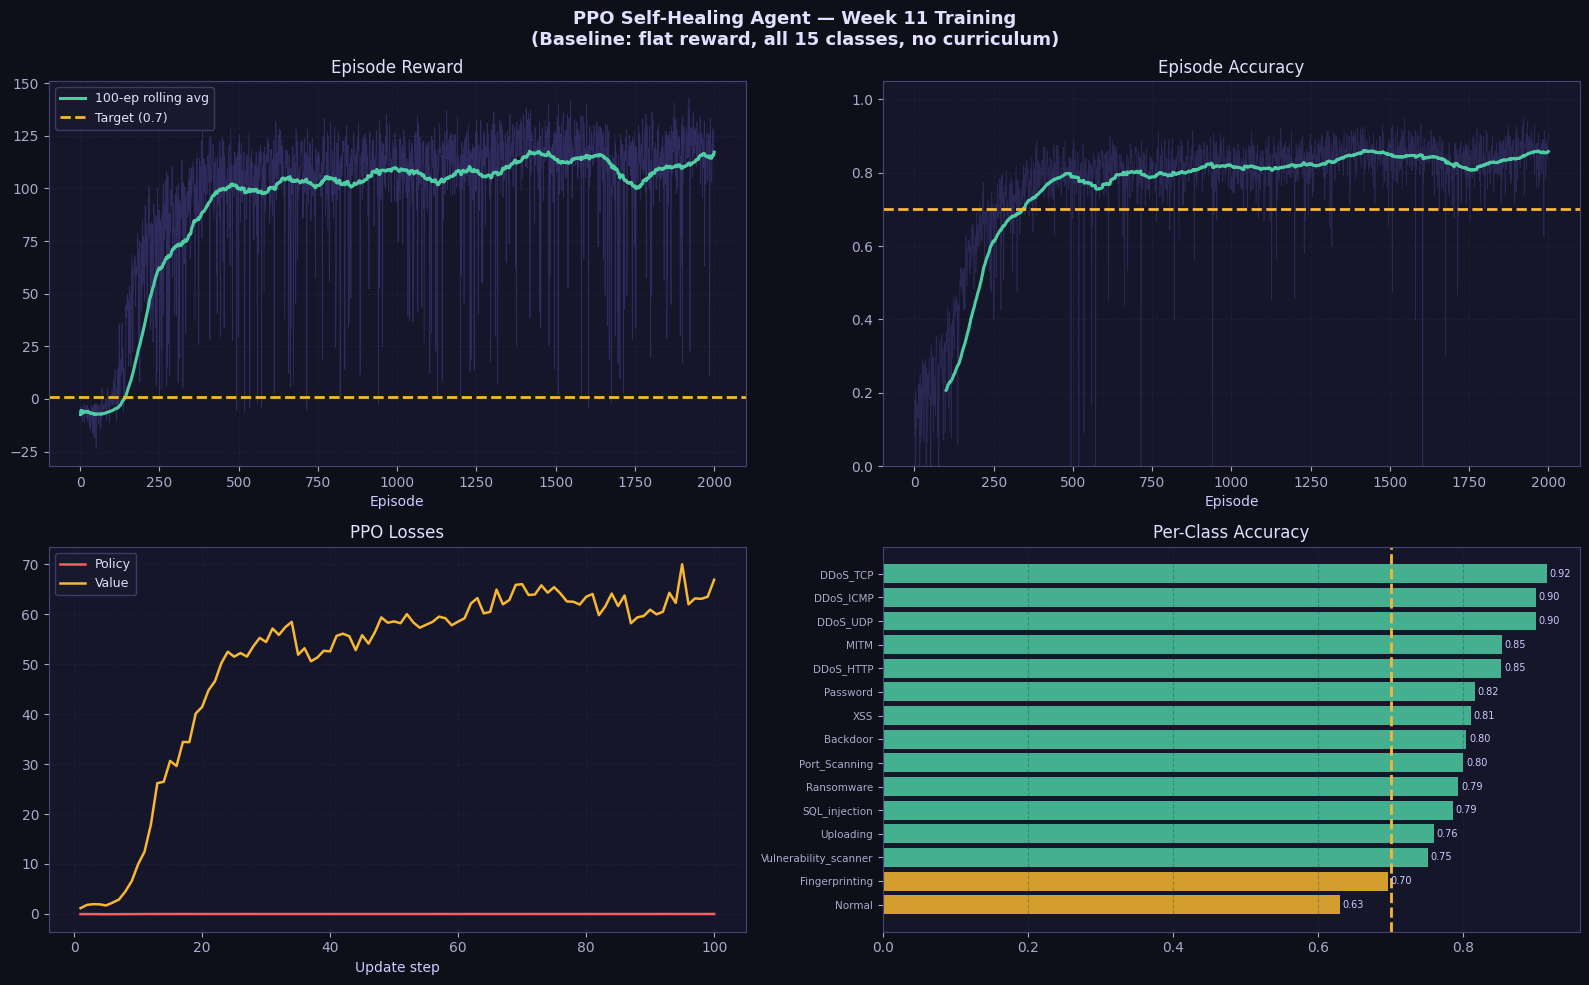

💾 Saved → ..\outputs\figures/nb11_training_curves.png


In [7]:
# ── Training curves ━━━━━━━━
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'PPO Self-Healing Agent — Week 11 Training\n'
    '(Baseline: flat reward, all 15 classes, no curriculum)',
    fontsize=13, fontweight='bold', color='#e0e0ff'
)
eps_x = list(range(1, N_EPISODES + 1))

ax = axes[0, 0]
ax.plot(eps_x, history['ep_rewards'],
        color=ACCENT, alpha=0.25, linewidth=0.5)
ax.plot(eps_x, history['rolling_reward'],
        color=GREEN, linewidth=2.2, label='100-ep rolling avg')
ax.axhline(TARGET_REWARD, color=YELLOW, linewidth=2,
           linestyle='--', label=f'Target ({TARGET_REWARD})')
ax.set_title('Episode Reward'); ax.set_xlabel('Episode')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
roll_acc = pd.Series(history['ep_accuracy']).rolling(100).mean()
ax.plot(eps_x, history['ep_accuracy'],
        color=ACCENT, alpha=0.2, linewidth=0.5)
ax.plot(eps_x, roll_acc, color=GREEN, linewidth=2.2)
ax.axhline(TARGET_REWARD, color=YELLOW, linewidth=2, linestyle='--')
ax.set_title('Episode Accuracy'); ax.set_xlabel('Episode')
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)

upd_x = list(range(1, len(history['policy_loss']) + 1))
ax = axes[1, 0]
if upd_x:
    ax.plot(upd_x, history['policy_loss'],
            color=RED, linewidth=1.8, label='Policy')
    ax.plot(upd_x, history['value_loss'],
            color=YELLOW, linewidth=1.8, label='Value')
    ax.set_title('PPO Losses'); ax.set_xlabel('Update step')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
cls_acc = {
    cls: class_correct[cls] / max(class_total[cls], 1)
    for cls in CLASS_NAMES
}
sorted_cls = sorted(cls_acc.items(), key=lambda x: -x[1])
c_names = [x[0] for x in sorted_cls]
c_vals  = [x[1] for x in sorted_cls]
colors  = [GREEN if v >= TARGET_REWARD else YELLOW if v >= 0.5 else RED
           for v in c_vals]
bars = ax.barh(range(len(c_names)), c_vals,
               color=colors, edgecolor='none', alpha=0.85)
ax.set_yticks(range(len(c_names)))
ax.set_yticklabels(c_names, fontsize=7.5)
ax.axvline(TARGET_REWARD, color=YELLOW, linewidth=2, linestyle='--')
ax.set_title('Per-Class Accuracy'); ax.invert_yaxis()
ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7, color='#ccccff')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'nb11_training_curves.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUT_DIR}/nb11_training_curves.png')

---
## ✅ Summary — Week 11 Outputs

| Artefact | Location |
|----------|----------|
| Best agent | `checkpoints/ppo_agent.pt` |
| Last agent | `checkpoints/ppo_agent_last.pt` |
| Training curves | `outputs/figures/nb11_training_curves.png` |

---

## 🔗 What NB12 receives from this notebook

```python
# NB12 loads the best checkpoint:
ckpt = torch.load('checkpoints/ppo_agent.pt')

# Keys NB12 uses:
ckpt['model_state_dict']   # → agent.network.load_state_dict(...)
ckpt['optimizer_state']    # → agent.optimizer.load_state_dict(...)
ckpt['state_dim']          # → verified = 30
ckpt['action_dim']         # → verified = 5
ckpt['hidden_dim']         # → 128
ckpt['class_names']        # → verified matches CLASS_NAMES
ckpt['episode']            # → warm-start episode number
ckpt['total_steps']        # → carried forward
ckpt['best_reward']        # → baseline for improvement tracking
```

---

## 💜 Week 12 — Reward Tuning + Curriculum Learning

Problems this agent may have:
- Rare classes (MITM, Fingerprinting, Ransomware) have low recall
- Cold-start on all 15 classes simultaneously is hard
- Flat reward gives sparse signal

Week 12 will fix these with:
1. **RewardEngine v2** — dense shaped rewards (7 components)
2. **CurriculumScheduler** — introduce classes gradually (2→6→10→15)
3. **CurriculumSecurityEnv** — extends THIS NetworkSecurityEnv
4. **Warm start** — loads `ppo_agent.pt` from this notebook